<a href="https://colab.research.google.com/github/coderMassive/Antimicrobial-Peptide-Representation/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AlphaFold

In [ ]:
!pip install biopython
import requests
from Bio.PDB import PDBParser, PPBuilder
import os
import re
import hashlib
import random
from sys import version_info
import sys
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from Bio import BiopythonDeprecationWarning
warnings.simplefilter(action='ignore', category=BiopythonDeprecationWarning)
from pathlib import Path
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import Bio.PDB
import pandas as pd
import glob

python_version = f"{version_info.major}.{version_info.minor}"

if not os.path.isfile("COLABFOLD_READY"):
  print("installing colabfold...")
  os.system("pip install -q --no-warn-conflicts 'colabfold[alphafold-minus-jax] @ git+https://github.com/sokrypton/ColabFold'")
  if os.environ.get('TPU_NAME', False) != False:
    os.system("pip uninstall -y jax jaxlib")
    os.system("pip install --no-warn-conflicts --upgrade dm-haiku==0.0.10 'jax[cuda12_pip]'==0.3.25 -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/colabfold colabfold")
  os.system("ln -s /usr/local/lib/python3.*/dist-packages/alphafold alphafold")
  # hack to fix TF crash
  os.system("rm -f /usr/local/lib/python3.*/dist-packages/tensorflow/core/kernels/libtfkernel_sobol_op.so /usr/local/lib/python3.*/dist-packages/tensorflow/lite/python/*/*.so")
  os.system("touch COLABFOLD_READY")

from colabfold.download import download_alphafold_params, default_data_dir
from colabfold.utils import setup_logging
from colabfold.batch import get_queries, run, set_model_type
from colabfold.plot import plot_msa_v2
from colabfold.colabfold import plot_protein

def add_hash(x,y):
  return x+"_"+hashlib.sha1(y.encode()).hexdigest()[:5]

# check if directory with jobname exists
def check(folder):
  if os.path.exists(folder):
    return False
  else:
    return True

df = pd.read_csv("all_veltri.csv")
for i in range(10):
  sequence = df.iloc[i]["aa_seq"]

  query_sequence = sequence
  jobname = 'test'
  num_relax = 0
  template_mode = "none"

  # remove whitespaces
  query_sequence = "".join(query_sequence.split())

  basejobname = "".join(jobname.split())
  basejobname = re.sub(r'\W+', '', basejobname)
  jobname = add_hash(basejobname, query_sequence)

  if not check(jobname):
    n = 0
    while not check(f"{jobname}_{n}"): n += 1
    jobname = f"{jobname}_{n}"

  # make directory to save results
  os.makedirs(jobname, exist_ok=True)

  # save queries
  queries_path = os.path.join(jobname, f"{jobname}.csv")
  with open(queries_path, "w") as text_file:
    text_file.write(f"id,sequence\n{jobname},{query_sequence}")

  custom_template_path = None
  a3m_file = os.path.join(jobname,f"{jobname}.a3m")

  PYTHON_VERSION = python_version

  model_type = "auto"
  num_recycles = "3"
  recycle_early_stop_tolerance = "auto"
  relax_max_iterations = 200
  pairing_strategy = "greedy"
  calc_extra_ptm = False

  msa_mode = "mmseqs2_uniref_env"
  pair_mode = "unpaired_paired"
  max_msa = "auto"
  num_seeds = 1
  use_dropout = False

  num_recycles = None if num_recycles == "auto" else int(num_recycles)
  recycle_early_stop_tolerance = None if recycle_early_stop_tolerance == "auto" else float(recycle_early_stop_tolerance)
  if max_msa == "auto": max_msa = None

  save_all = False
  save_recycles = False
  save_to_google_drive = False
  dpi = 200

  display_images = True

  try:
    K80_chk = os.popen('nvidia-smi | grep "Tesla K80" | wc -l').read()
  except:
    K80_chk = "0"
    pass
  if "1" in K80_chk:
    print("WARNING: found GPU Tesla K80: limited to total length < 1000")
    if "TF_FORCE_UNIFIED_MEMORY" in os.environ:
      del os.environ["TF_FORCE_UNIFIED_MEMORY"]
    if "XLA_PYTHON_CLIENT_MEM_FRACTION" in os.environ:
      del os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"]

  def input_features_callback(input_features):
    if display_images:
      plot_msa_v2(input_features)
      plt.show()
      plt.close()

  def prediction_callback(protein_obj, length,
                          prediction_result, input_features, mode):
    model_name, relaxed = mode
    if not relaxed:
      if display_images:
        fig = plot_protein(protein_obj, Ls=length, dpi=150)
        plt.show()
        plt.close()

  result_dir = jobname
  log_filename = os.path.join(jobname,"log.txt")
  setup_logging(Path(log_filename))

  queries, is_complex = get_queries(queries_path)
  model_type = set_model_type(is_complex, model_type)

  if "multimer" in model_type and max_msa is not None:
    use_cluster_profile = False
  else:
    use_cluster_profile = True

  download_alphafold_params(model_type, Path("."))
  results = run(
      queries=queries,
      result_dir=result_dir,
      use_templates=False,
      custom_template_path=custom_template_path,
      num_relax=num_relax,
      msa_mode=msa_mode,
      model_type=model_type,
      num_models=5,
      num_recycles=num_recycles,
      relax_max_iterations=relax_max_iterations,
      recycle_early_stop_tolerance=recycle_early_stop_tolerance,
      num_seeds=num_seeds,
      use_dropout=use_dropout,
      model_order=[1,2,3,4,5],
      is_complex=is_complex,
      data_dir=Path("."),
      keep_existing_results=False,
      rank_by="auto",
      pair_mode=pair_mode,
      pairing_strategy=pairing_strategy,
      stop_at_score=float(100),
      prediction_callback=prediction_callback,
      dpi=dpi,
      zip_results=False,
      save_all=save_all,
      max_msa=max_msa,
      use_cluster_profile=use_cluster_profile,
      input_features_callback=input_features_callback,
      save_recycles=save_recycles,
      user_agent="colabfold/google-colab-main",
      calc_extra_ptm=calc_extra_ptm,
  )

ERROR: Operation cancelled by user


KeyboardInterrupt: 

## ESMFold

In [ ]:
version = "1"
model_name = "esmfold_v0.model" if version == "0" else "esmfold.model"
import os, time
if not os.path.isfile(model_name):
  os.system("apt-get install aria2 -qq")
  os.system(f"aria2c -q -x 16 https://colabfold.steineggerlab.workers.dev/esm/{model_name} &")

  if not os.path.isfile("finished_install"):
    print("installing libs...")
    os.system("pip install -q omegaconf pytorch_lightning biopython ml_collections einops py3Dmol modelcif")
    os.system("pip install -q git+https://github.com/NVIDIA/dllogger.git")

    print("installing openfold...")
    os.system(f"pip install -q git+https://github.com/sokrypton/openfold.git")

    print("installing esmfold...")
    os.system(f"pip install -q git+https://github.com/sokrypton/esm.git")
    os.system("touch finished_install")

  while not os.path.isfile(model_name):
    time.sleep(5)
  if os.path.isfile(f"{model_name}.aria2"):
    print("downloading params...")
  while os.path.isfile(f"{model_name}.aria2"):
    time.sleep(5)

from string import ascii_uppercase, ascii_lowercase
import hashlib, re, os
import numpy as np
import torch
from jax.tree_util import tree_map
import matplotlib.pyplot as plt
from scipy.special import softmax
import pandas as pd
import gc

def parse_output(output):
  pae = (output["aligned_confidence_probs"][0] * np.arange(64)).mean(-1) * 31
  plddt = output["plddt"][0,:,1]

  bins = np.append(0,np.linspace(2.3125,21.6875,63))
  sm_contacts = softmax(output["distogram_logits"],-1)[0]
  sm_contacts = sm_contacts[...,bins<8].sum(-1)
  xyz = output["positions"][-1,0,:,1]
  mask = output["atom37_atom_exists"][0,:,1] == 1
  o = {"pae":pae[mask,:][:,mask],
       "plddt":plddt[mask],
       "sm_contacts":sm_contacts[mask,:][:,mask],
       "xyz":xyz[mask]}
  return o

def get_hash(x): return hashlib.sha1(x.encode()).hexdigest()
alphabet_list = list(ascii_uppercase+ascii_lowercase)

df = pd.read_csv("all_veltri.csv")
model_name_ = None
for i in range(len(df)):
  sequence = df.iloc[i]["aa_seq"]

  jobname = "test"
  jobname = re.sub(r'\W+', '', jobname)[:50]

  sequence = re.sub("[^A-Z:]", "", sequence.replace("/",":").upper())
  sequence = re.sub(":+",":",sequence)
  sequence = re.sub("^[:]+","",sequence)
  sequence = re.sub("[:]+$","",sequence)
  copies = 1
  if copies == "" or copies <= 0: copies = 1
  sequence = ":".join([sequence] * copies)
  num_recycles = 3
  chain_linker = 25

  ID = jobname+"_"+get_hash(sequence)[:5]
  seqs = sequence.split(":")
  lengths = [len(s) for s in seqs]
  length = sum(lengths)
  print("length",length)

  u_seqs = list(set(seqs))
  if len(seqs) == 1: mode = "mono"
  elif len(u_seqs) == 1: mode = "homo"
  else: mode = "hetero"

  if "model" not in dir() or model_name != model_name_:
    if "model" in dir():
      # delete old model from memory
      del model
      gc.collect()
      if torch.cuda.is_available():
        torch.cuda.empty_cache()

    model = torch.load(model_name, weights_only=False)
    model.eval().cuda().requires_grad_(False)
    model_name_ = model_name

  # optimized for Tesla T4
  if length > 700:
    model.set_chunk_size(64)
  else:
    model.set_chunk_size(128)

  torch.cuda.empty_cache()
  output = model.infer(sequence,
                      num_recycles=num_recycles,
                      chain_linker="X"*chain_linker,
                      residue_index_offset=512)

  pdb_str = model.output_to_pdb(output)[0]
  output = tree_map(lambda x: x.cpu().numpy(), output)
  ptm = output["ptm"][0]
  plddt = output["plddt"][0,...,1].mean()
  O = parse_output(output)
  print(f'ptm: {ptm:.3f} plddt: {plddt:.3f}')
  os.system("mkdir -p pdbs")
  prefix = f"pdbs/{ID}"
  with open(f"{prefix}.pdb","w") as out:
    out.write(pdb_str)

import shutil
shutil.make_archive("pdbs", "zip", "pdbs")
from google.colab import files
files.download("pdbs.zip")

Streaming output truncated to the last 5000 lines.
length 15
ptm: 0.038 plddt: 91.701
length 37
ptm: 0.644 plddt: 88.024
length 28
ptm: 0.169 plddt: 53.466
length 32
ptm: 0.510 plddt: 86.586
length 26
ptm: 0.376 plddt: 91.434
length 43
ptm: 0.740 plddt: 92.426
length 53
ptm: 0.118 plddt: 65.614
length 24
ptm: 0.180 plddt: 74.349
length 46
ptm: 0.178 plddt: 47.804
length 40
ptm: 0.646 plddt: 86.013
length 51
ptm: 0.261 plddt: 51.028
length 19
ptm: 0.027 plddt: 81.404
length 65
ptm: 0.203 plddt: 40.679
length 33
ptm: 0.623 plddt: 89.526
length 44
ptm: 0.300 plddt: 51.835
length 77
ptm: 0.596 plddt: 70.994
length 31
ptm: 0.461 plddt: 82.486
length 43
ptm: 0.328 plddt: 54.090
length 89
ptm: 0.119 plddt: 58.946
length 22
ptm: 0.098 plddt: 68.119
length 31
ptm: 0.444 plddt: 78.991
length 42
ptm: 0.110 plddt: 39.513
length 31
ptm: 0.514 plddt: 89.518
length 13
ptm: 0.021 plddt: 76.497
length 40
ptm: 0.630 plddt: 83.174
length 13
ptm: 0.011 plddt: 65.489
length 27
ptm: 0.489 plddt: 94.541
leng

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Structure Summary

In [ ]:
import os
import glob
import shutil
import pandas as pd
import hashlib
import numpy as np
from Bio.PDB import PDBParser
from scipy.spatial.distance import pdist
import requests

def get_mean_plddt_from_pdb(pdb_file):
    plddts = []
    with open(pdb_file, 'r') as f:
        for line in f:
            if line.startswith("ATOM") and line[12:16].strip() == "CA":
                try:
                    plddts.append(float(line[60:66]))
                except ValueError:
                    continue
    if plddts:
        return sum(plddts) / len(plddts)
    return None

def analyze_structure(pdb_file):
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure('protein', pdb_file)

    atoms = list(structure.get_atoms())
    residues = [r for r in structure.get_residues() if r.id[0] == ' ']

    num_atoms = len(atoms)
    num_residues = len(residues)

    coords = np.array([atom.get_coord() for atom in atoms])
    if len(coords) == 0:
        return num_residues, num_atoms, None, None

    com = coords.mean(axis=0)
    rg = np.sqrt(np.sum((coords - com)**2) / len(coords))

    ca_atoms = [atom for atom in atoms if atom.get_name() == 'CA']
    ca_coords = np.array([atom.get_coord() for atom in ca_atoms])

    if len(ca_coords) > 1:
        max_ca_dist = np.max(pdist(ca_coords))
    else:
        max_ca_dist = 0.0

    return num_residues, num_atoms, rg, max_ca_dist

def add_hash(x, y):
    return x + "_" + hashlib.sha1(y.encode()).hexdigest()[:5]

out_dir = "predicted_structures"
os.makedirs(out_dir, exist_ok=True)
summary_records = []

df_results = pd.read_csv("all_veltri.csv")

for i in range(10):
    row = df_results.iloc[i]
    peptide_id = row.iloc[0]
    sequence = row["aa_seq"]
    length = row["aa_len"]

    query_sequence = "".join(sequence.split())
    basejobname = "test"
    jobname = add_hash(basejobname, query_sequence)

    pdbs = glob.glob(f"{jobname}/out.pdb")

    if pdbs:
        af_pdb_path = pdbs[0]
        new_pdb_filename = f"{peptide_id}.pdb"
        new_pdb_path = os.path.join(out_dir, new_pdb_filename)

        shutil.copy(af_pdb_path, new_pdb_path)

        confidence_score = get_mean_plddt_from_pdb(new_pdb_path)
        num_res, num_atoms, rg, max_ca_dist = analyze_structure(new_pdb_path)

        summary_records.append({
            "Peptide ID": peptide_id,
            "Amino acid sequence": sequence,
            "Sequence length": length,
            "PDB filename": new_pdb_filename,
            "Prediction confidence score": confidence_score,
            "Number of residues": num_res,
            "Number of atoms": num_atoms,
            "Radius of gyration": rg,
            "Max C-alpha distance": max_ca_dist
        })
    else:
        print(f"Could not find prediction for {peptide_id} in {jobname}")

summary_df = pd.DataFrame(summary_records)
summary_csv_path = "structure_summary.csv"
summary_df.to_csv(summary_csv_path, index=False)

shutil.make_archive(out_dir, 'zip', out_dir)

display(summary_df)


,Peptide ID,Amino acid sequence,Sequence length,PDB filename,Prediction confidence score,Number of residues,Number of atoms,Radius of gyration,Max C-alpha distance
0,AP00085,SLFSLIKAGAKFLGKNLLKQGACYAACKASKQC,33,AP00085.pdb,82.989091,33,240,14.477857,45.563238
1,AP00652,GIMDTVKNVAKNLAGQLLDKLKCKITAC,28,AP00652.pdb,92.748929,28,205,12.103570,38.054010
2,AP00714,GYGCPFNQYQCHSHCSGIRGYKGGYCKGTFKQTCKCY,37,AP00714.pdb,91.784054,37,289,9.670053,27.257291
3,AP00269,LSCKRGTCHFGRCPSHLIKGSCSGG,25,AP00269.pdb,47.060800,25,177,9.370131,23.771250
4,AP00765,MHDFWVLWVLLEYIYNSACSVLSATSSVSSRVLNRSLQVKVVKITN,46,AP00765.pdb,65.353913,46,369,21.209879,73.337196
5,AP01325,QPFIPRPIDTCRLRNGICFPGICRRPYYWIGTCNNGIGSCCARGWRS,47,AP01325.pdb,77.164894,47,374,12.715754,46.813662
6,AP02409,AIFIFIRWLLKLGHHGRAPP,20,AP02409.pdb,70.928000,20,167,10.279766,34.512343
7,AP00263,GLLQTIKEKLESLESLAKGIVSGIQA,26,AP00263.pdb,94.797308,26,190,11.579260,37.964708
8,AP02481,GIGKFLHSAGKFGKAFIGEIMKS,23,AP02481.pdb,92.989130,23,170,10.571720,34.488730
9,AP00613,RVKRFWPLVPVAINTVAAGINLYKAIRRK,29,AP00613.pdb,90.444138,29,237,14.512792,43.558363


## Contact Map Dataset

In [ ]:
import os
import glob
import hashlib
import shutil
import pandas as pd
import numpy as np

!pip install contact_map mdtraj
from contact_map import ContactFrequency
import mdtraj as md

out_dir = "dataset"
os.makedirs(out_dir, exist_ok=True)

df_results = pd.read_csv("all_veltri.csv")

target_size = 200

for i in range(len(df_results)):
    row = df_results.iloc[i]
    peptide_id = row.iloc[0]
    sequence = row["aa_seq"]

    query_sequence = "".join(sequence.split())
    basejobname = "test"
    jobname = basejobname + "_" + hashlib.sha1(query_sequence.encode()).hexdigest()[:5]

    pdb = glob.glob(f"pdbs/{jobname}.pdb")[0]
    traj = md.load(pdb)
    cm = ContactFrequency(traj[0])
    matrix = cm.residue_contacts.df.to_numpy()
    matrix = np.nan_to_num(matrix, nan=0.0)

    current_size = matrix.shape[0]
    if current_size < target_size:
        pad_width = target_size - current_size
        matrix = np.pad(matrix, ((0, pad_width), (0, pad_width)), mode='constant', constant_values=0.0)
    elif current_size > target_size:
        matrix = matrix[:target_size, :target_size]

    np.save(os.path.join(out_dir, f"{peptide_id}.npy"), matrix)

shutil.make_archive(out_dir, "zip", out_dir)

from google.colab import files
files.download(f"{out_dir}.zip")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 88.7 MB/s eta 0:00:00


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Convolutional Autoencoder

In [ ]:
import os
import glob
import numpy as np
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

input_img = layers.Input(shape=(200, 200, 1))

# --- Encoder ---
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 100x100
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 50x50
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x) # 25x25
x = layers.Dropout(0.2)(x)

# --- Bottleneck ---
x = layers.Flatten()(x)
x = layers.Dropout(0.3)(x)
bottleneck = layers.Dense(1024, activation='relu', name='bottleneck')(x) # Fixed-size vector

# --- Decoder ---
x = layers.Dense(25 * 25 * 128, activation='relu')(bottleneck)
x = layers.Reshape((25, 25, 128))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 50x50

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 100x100

x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x) # 200x200

output_img = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# --- Create Model ---
model = Model(input_img, output_img)
model.compile(optimizer='adam', loss='binary_crossentropy')
model.summary()

# --- Prepare Data ---
npy_folder = "dataset"
npy_files = glob.glob(os.path.join(npy_folder, "*.npy"))

X = np.zeros((len(npy_files), 200, 200))
for (i, npy_path) in enumerate(npy_files):
    X[i] = np.load(npy_path)

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# --- Train ---
history = model.fit(X_train, X_train,
                    epochs=100,
                    batch_size=16,
                    shuffle=True,
                    validation_data=(X_test, X_test),
                    callbacks=[early_stop])


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 1024)           │    81,921,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 80000)          │    82,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 50, 50, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 50, 50, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 100, 100, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 100, 100, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 200, 200, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 200, 200, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,253,825 (626.58 MB)

 Trainable params: 164,253,825 (626.58 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - loss: 0.0285 - val_loss: 0.0060
Epoch 2/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0056 - val_loss: 0.0054
Epoch 3/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0051 - val_loss: 0.0053
Epoch 4/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0050 - val_loss: 0.0051
Epoch 5/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0046 - val_loss: 0.0048
Epoch 6/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0043 - val_loss: 0.0045
Epoch 7/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0041 - val_loss: 0.0045
Epoch 8/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0040 - val_loss: 0.0043
Epoch 9/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0039 - val_loss: 0.0041
Epoch 10/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0037 - val_loss: 0.0040
Epoch 11/100
178/178 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 12/100
178/178 ━━━━━━━━

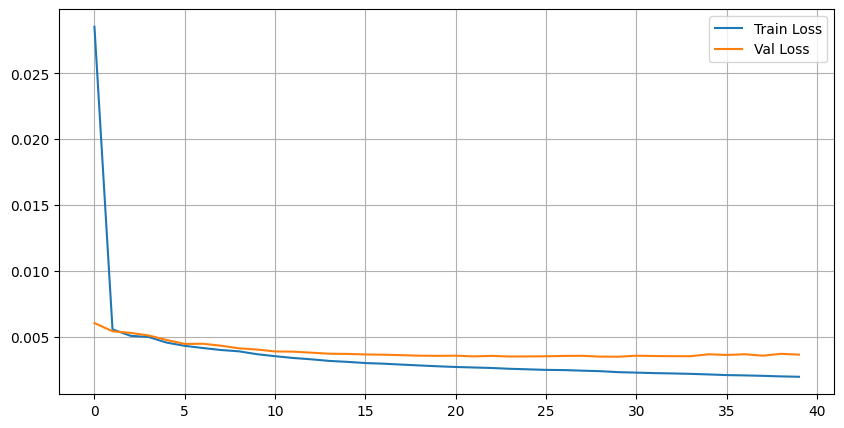

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


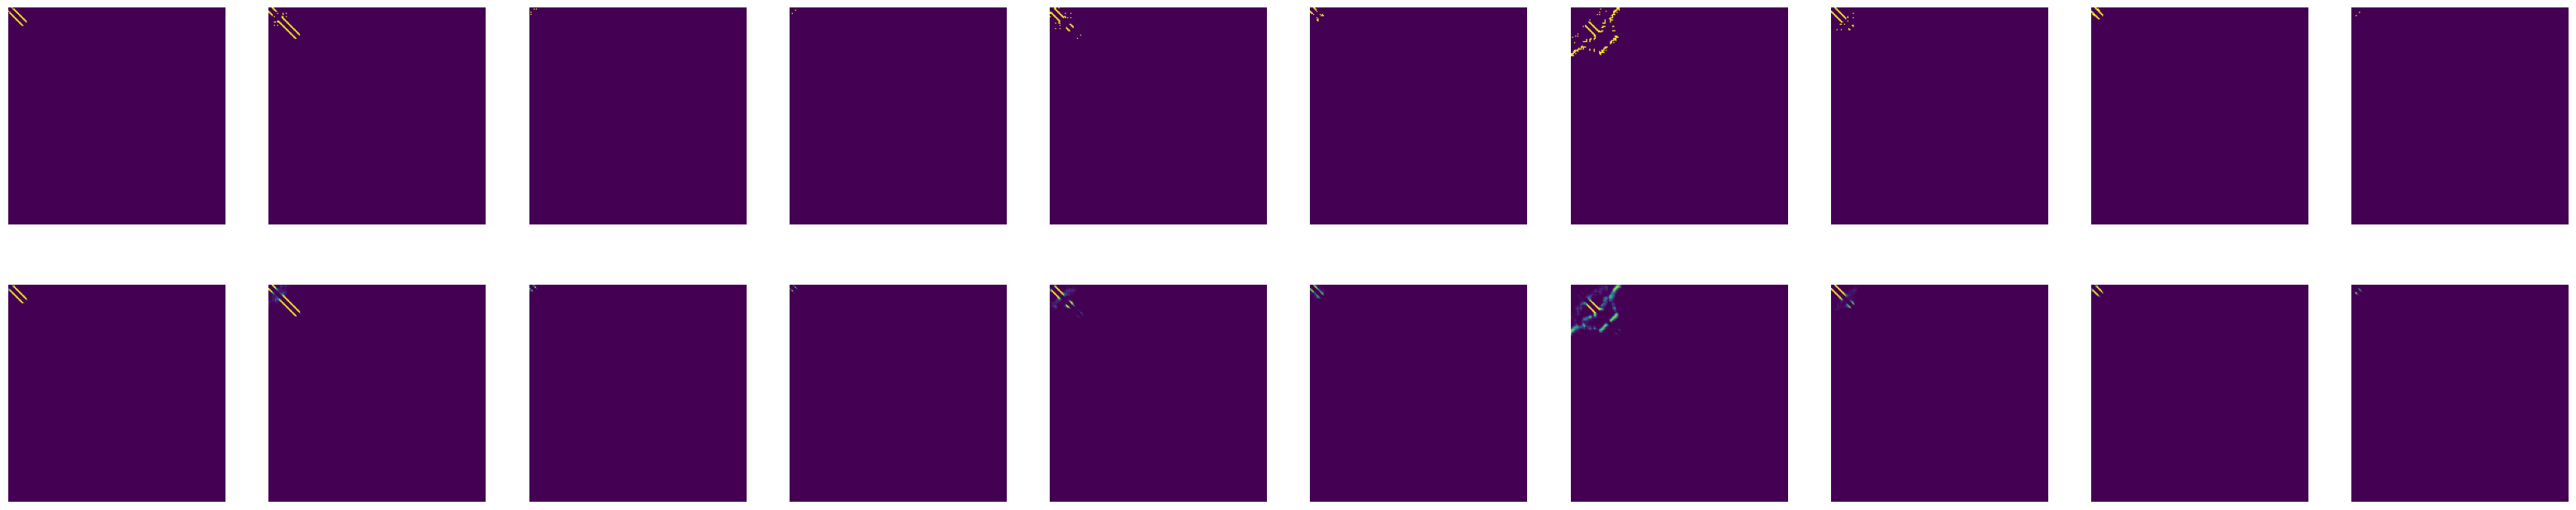

In [ ]:
import matplotlib.pyplot as plt

result_imgs = model.predict(X_test[:11])

n = 10
plt.figure(figsize=(40, 8))
for i in range(n):
  ax = plt.subplot(2, n, i+1)
  plt.imshow(X_test[i])
  plt.axis('off')
  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(result_imgs[i])
  plt.axis('off')
plt.show()


In [ ]:
!pip install umap-learn
import umap
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

encoder = Model(inputs=model.input, outputs=model.get_layer('bottleneck').output)

X_full = np.expand_dims(X, axis=-1)
bottleneck_features = encoder.predict(X_full)

reducer = umap.UMAP(n_components=2, random_state=42)
embedding = reducer.fit_transform(bottleneck_features)

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], alpha=0.7, s=10)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.grid(True)
plt.show()

## Graph Autoencoder

In [17]:
!pip install torch_geometric

import os
import glob
import numpy as np
import torch
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_batch
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch_geometric.nn import GATConv

# --- Prepare Dataset ---
npy_folder = "dataset"
npy_files = glob.glob(os.path.join(npy_folder, "*.npy"))

dataset = []

for npy_path in npy_files:
    adj_matrix = np.load(npy_path)

    adj_tensor = torch.tensor(adj_matrix, dtype=torch.float).unsqueeze(0) # [1, 200, 200]

    rows, cols = np.where(adj_matrix > 0)
    edge_index = torch.tensor(np.array([rows, cols]), dtype=torch.long)
    edge_attr = torch.tensor(adj_matrix[rows, cols], dtype=torch.float)

    num_nodes = adj_matrix.shape[0]

    x = torch.eye(num_nodes, dtype=torch.float)

    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=adj_tensor)
    dataset.append(data)

train_dataset, test_dataset = train_test_split(dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# --- Define Model ---
class GraphAE(torch.nn.Module):
    def __init__(self, num_nodes=200):
        super().__init__()
        self.num_nodes = num_nodes
        self.node_dim = 16

        # GAT Encoder
        self.conv1 = GATConv(num_nodes, 32, heads=2, concat=True)
        self.conv2 = GATConv(64, self.node_dim, heads=1, concat=False)

        # Fixed Size Vector Bottleneck
        self.flatten_dim = num_nodes * self.node_dim
        self.bottleneck = torch.nn.Linear(self.flatten_dim, 1024)

        # Decoder
        self.decoder_matrix = torch.nn.Linear(1024, num_nodes * num_nodes)

    def encode(self, x, edge_index, batch):
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.2, training=self.training)
        x = F.relu(self.conv2(x, edge_index))

        x_dense, _ = to_dense_batch(x, batch, max_num_nodes=self.num_nodes)

        x_flat = x_dense.view(-1, self.flatten_dim)
        z = F.relu(self.bottleneck(x_flat))
        return z

    def decode(self, z):
        adj_rec_flat = self.decoder_matrix(z)
        adj_rec = adj_rec_flat.view(-1, self.num_nodes, self.num_nodes)
        return adj_rec

    def forward(self, x, edge_index, batch):
        z = self.encode(x, edge_index, batch)
        adj_rec = self.decode(z)
        return adj_rec, z

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GraphAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = torch.nn.BCEWithLogitsLoss()

# --- Train Model ---
epochs = 50

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_data in train_loader:
        batch_data = batch_data.to(device)
        optimizer.zero_grad()

        adj_rec, _ = model(batch_data.x, batch_data.edge_index, batch_data.batch)

        loss = criterion(adj_rec, batch_data.y.squeeze(1))

        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_data.num_graphs

    train_loss = total_loss / len(train_loader.dataset)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch_data in test_loader:
            batch_data = batch_data.to(device)
            adj_rec, _ = model(batch_data.x, batch_data.edge_index, batch_data.batch)
            loss = criterion(adj_rec, batch_data.y.squeeze(1))
            val_loss += loss.item() * batch_data.num_graphs

    val_loss = val_loss / len(test_loader.dataset)
    print(f'Epoch {epoch+1:>3} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

Epoch   1 | Train Loss: 0.0607 | Val Loss: 0.0104
Epoch   2 | Train Loss: 0.0106 | Val Loss: 0.0110
Epoch   3 | Train Loss: 0.0106 | Val Loss: 0.0108
Epoch   4 | Train Loss: 0.0105 | Val Loss: 0.0105
Epoch   5 | Train Loss: 0.0104 | Val Loss: 0.0108
Epoch   6 | Train Loss: 0.0102 | Val Loss: 0.0103
Epoch   7 | Train Loss: 0.0099 | Val Loss: 0.0100
Epoch   8 | Train Loss: 0.0097 | Val Loss: 0.0100
Epoch   9 | Train Loss: 0.0095 | Val Loss: 0.0098
Epoch  10 | Train Loss: 0.0094 | Val Loss: 0.0094
Epoch  11 | Train Loss: 0.0092 | Val Loss: 0.0094
Epoch  12 | Train Loss: 0.0091 | Val Loss: 0.0095
Epoch  13 | Train Loss: 0.0090 | Val Loss: 0.0095
Epoch  14 | Train Loss: 0.0090 | Val Loss: 0.0093
Epoch  15 | Train Loss: 0.0089 | Val Loss: 0.0091
Epoch  16 | Train Loss: 0.0089 | Val Loss: 0.0091
Epoch  17 | Train Loss: 0.0088 | Val Loss: 0.0091
Epoch  18 | Train Loss: 0.0088 | Val Loss: 0.0091
Epoch  19 | Train Loss: 0.0088 | Val Loss: 0.0091
Epoch  20 | Train Loss: 0.0087 | Val Loss: 0.0091


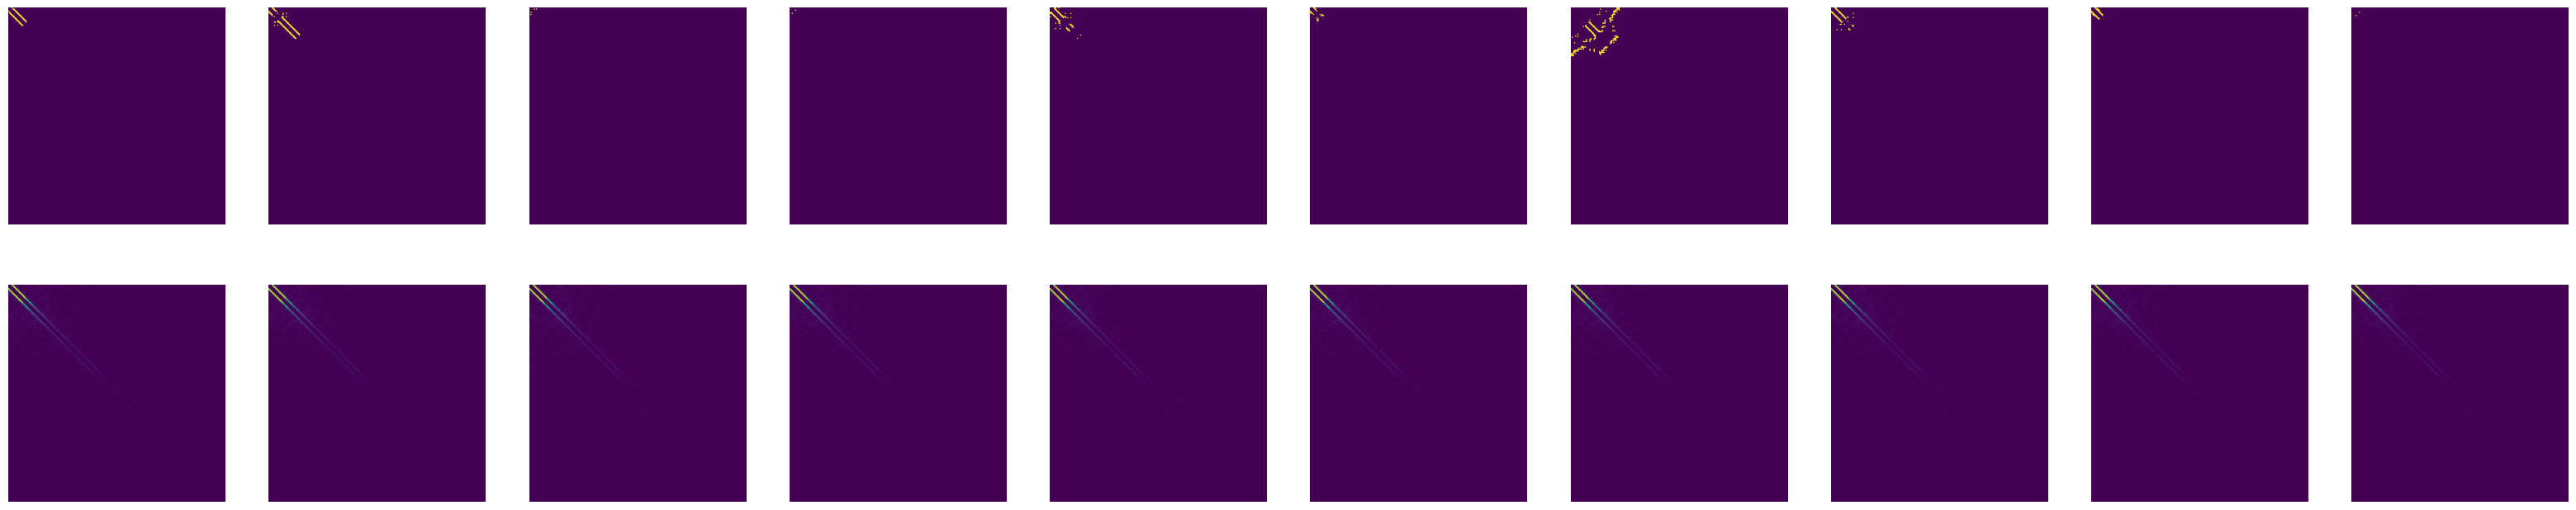

In [18]:
import matplotlib.pyplot as plt
import torch

model.eval()

sample_data = next(iter(test_loader)).to(device)

with torch.no_grad():
    adj_rec_logits, _ = model(sample_data.x, sample_data.edge_index, sample_data.batch)
    adj_rec_probs = torch.sigmoid(adj_rec_logits).cpu().numpy()

ground_truth = sample_data.y.squeeze(1).cpu().numpy()

n = min(10, ground_truth.shape[0])
plt.figure(figsize=(40, 8))

for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(ground_truth[i], cmap='viridis')
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(adj_rec_probs[i], cmap='viridis')
    plt.axis('off')

plt.show()